# Tesla Stock Price Prediction using SimpleRNN and LSTM

**Domain:** Financial Services

**Problem Statement:**  
Develop deep learning models (SimpleRNN and LSTM) to predict Tesla's
closing stock price 1-day, 5-day and 10-day ahead, and compare their
performance.

## Project Objectives

- Analyze and preprocess Tesla stock price data.
- Perform exploratory data analysis and visualization.
- Build SimpleRNN and LSTM models.
- Predict 1-day, 5-day and 10-day stock prices.
- Evaluate models using MSE, RMSE and MAE.
- Tune LSTM hyperparameters using GridSearchCV.
- Compare SimpleRNN and LSTM performance.
- Analyze limitations and future improvements.

## Section 1: Import Libraries & Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

plt.style.use('seaborn-v0_8-darkgrid')
tf.random.set_seed(42)
np.random.seed(42)

print("All libraries imported successfully")

All libraries imported successfully


## Section 2: Load Dataset

In [2]:
candidate_paths = ["TSLA.csv", "/mnt/user-data/uploads/TSLA.csv"]
csv_path = next((p for p in candidate_paths if os.path.exists(p)), candidate_paths[0])

df = pd.read_csv(csv_path)
print(f"Dataset loaded successfully from: {csv_path}")
df.head()

Dataset loaded successfully from: TSLA.csv


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [3]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
2411,2020-01-28,568.489990,576.809998,558.080017,566.900024,566.900024,11788500
2412,2020-01-29,575.690002,589.799988,567.429993,580.989990,580.989990,17801500
2413,2020-01-30,632.419983,650.880005,618.000000,640.809998,640.809998,29005700
2414,2020-01-31,640.000000,653.000000,632.520020,650.570007,650.570007,15719300
2415,2020-02-03,673.690002,786.140015,673.520020,780.000000,780.000000,47065000


## Section 3: Data Understanding

In [4]:
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (2416, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


In [5]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


## Section 4: Data Cleaning

In [6]:
print("Missing Values:\n", df.isnull().sum())
print("\nDuplicate Records:", df.duplicated().sum())

Missing Values:
 Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Duplicate Records: 0


In [7]:
# Demonstrate the missing-value strategy on a simulated copy (real data has no gaps)
rng = np.random.RandomState(42)
demo = df.copy()
sim_idx = rng.choice(demo.index[20:-20], size=15, replace=False)
demo.loc[sim_idx, 'Adj Close'] = np.nan
print("Simulated NaNs:", demo['Adj Close'].isnull().sum())

demo['Adj Close'] = demo['Adj Close'].ffill().interpolate(method='linear')
print("After ffill + interpolate:", demo['Adj Close'].isnull().sum())

Simulated NaNs: 15
After ffill + interpolate: 0


In [8]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
print(df["Date"].dtype)

datetime64[ns]


In [9]:
df.set_index("Date", inplace=True)
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


## Section 5: Exploratory Data Analysis (EDA)

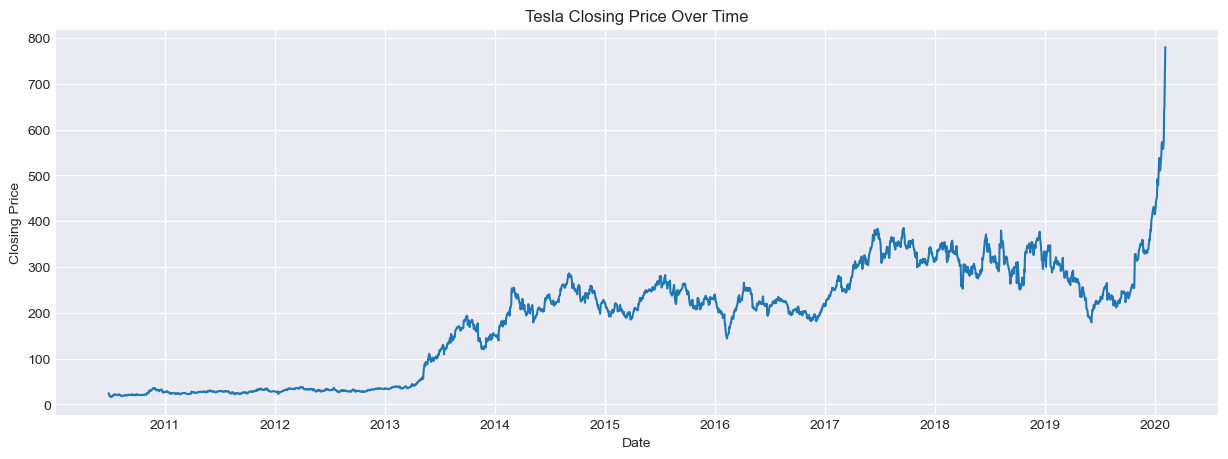

In [10]:
plt.figure(figsize=(15,5))
plt.plot(df["Close"])
plt.title("Tesla Closing Price Over Time")
plt.xlabel("Date"); plt.ylabel("Closing Price"); plt.grid(True)
plt.show()

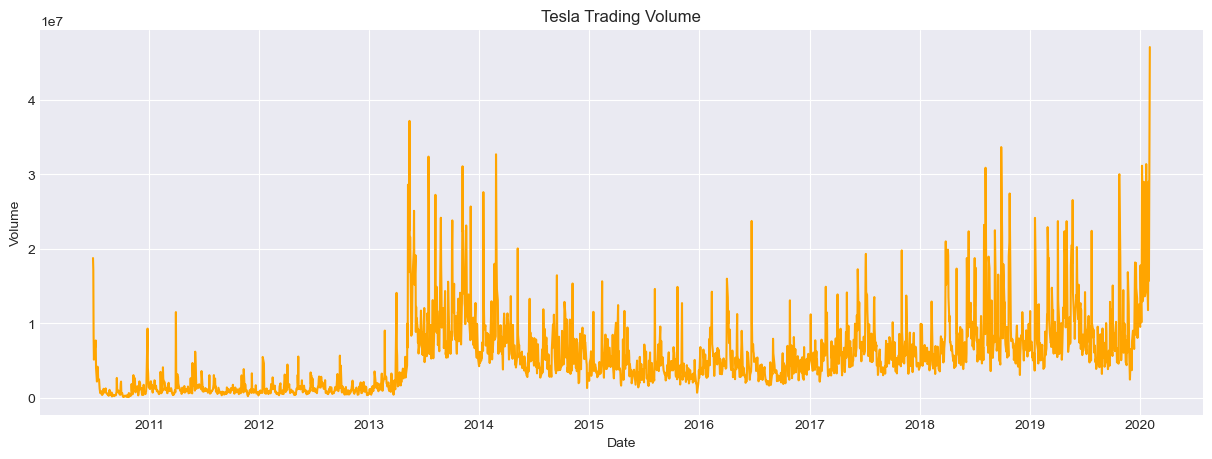

In [11]:
plt.figure(figsize=(15,5))
plt.plot(df["Volume"], color="orange")
plt.title("Tesla Trading Volume")
plt.xlabel("Date"); plt.ylabel("Volume"); plt.grid(True)
plt.show()

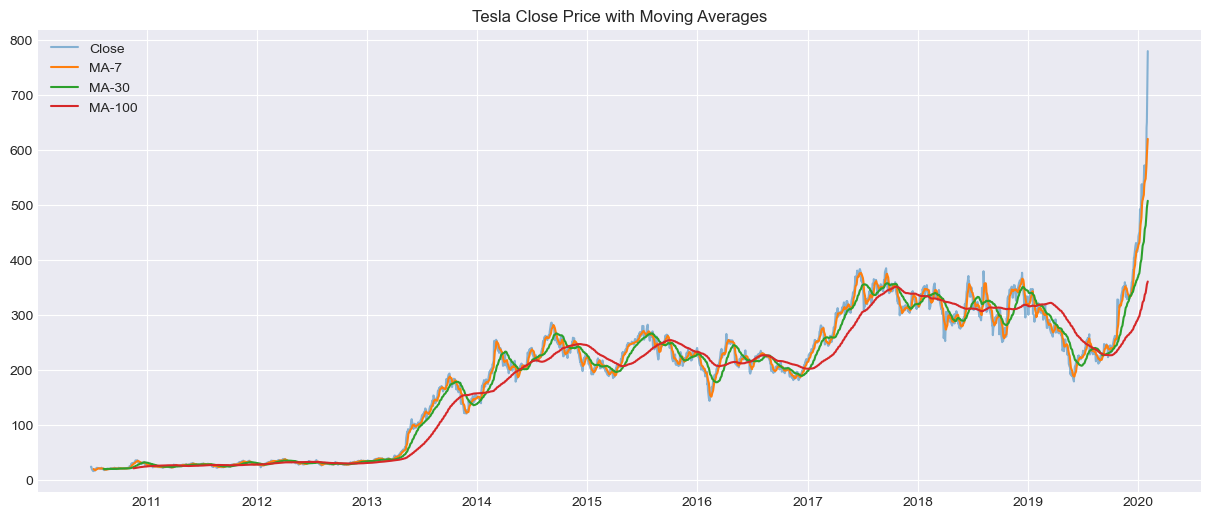

In [12]:
df["MA7"] = df["Close"].rolling(7).mean()
df["MA30"] = df["Close"].rolling(30).mean()
df["MA100"] = df["Close"].rolling(100).mean()

plt.figure(figsize=(15,6))
plt.plot(df["Close"], label="Close", alpha=0.5)
plt.plot(df["MA7"], label="MA-7")
plt.plot(df["MA30"], label="MA-30")
plt.plot(df["MA100"], label="MA-100")
plt.title("Tesla Close Price with Moving Averages")
plt.legend(); plt.show()


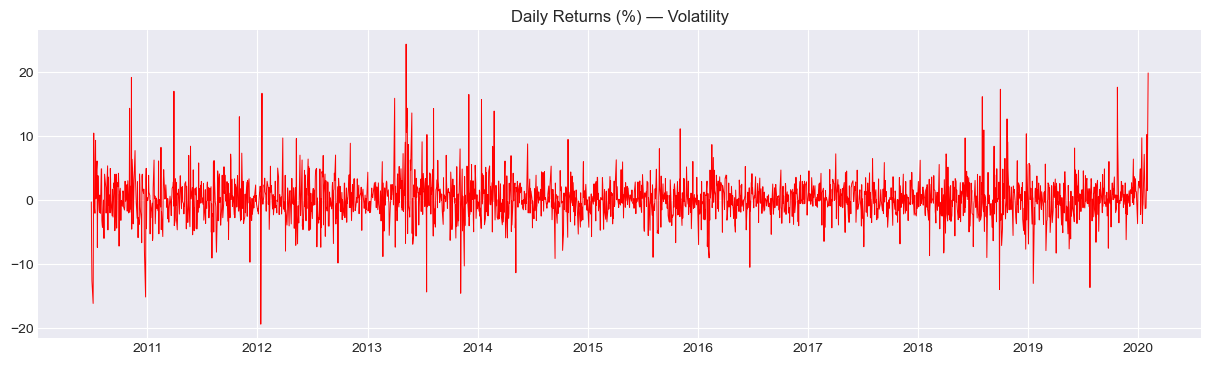

In [13]:
df["Daily_Return"] = df["Close"].pct_change() * 100
plt.figure(figsize=(15,4))
plt.plot(df["Daily_Return"], color="red", linewidth=0.7)
plt.title("Daily Returns (%) — Volatility")
plt.show()


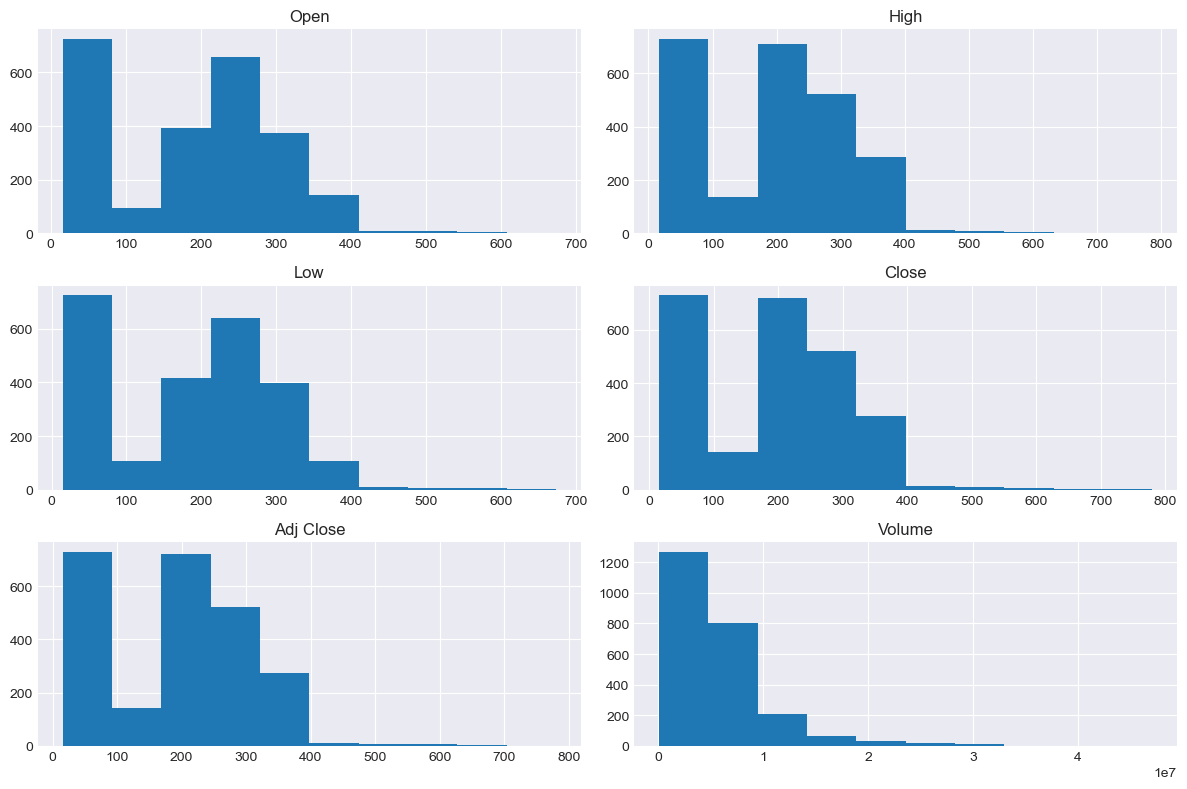

In [14]:
df[["Open","High","Low","Close","Adj Close","Volume"]].hist(figsize=(12,8))
plt.tight_layout(); plt.show()

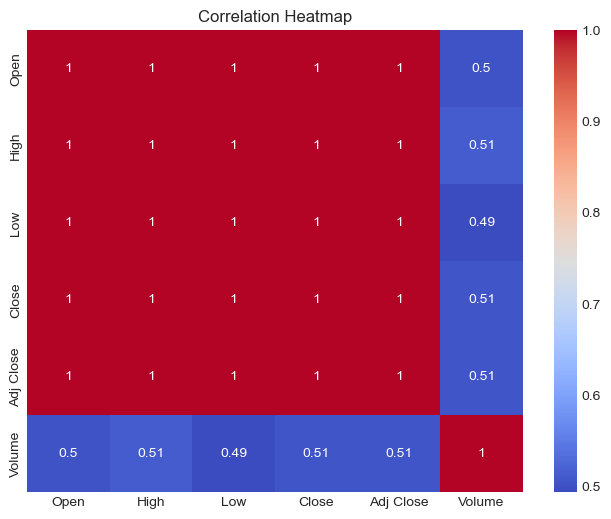

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(df[["Open","High","Low","Close","Adj Close","Volume"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

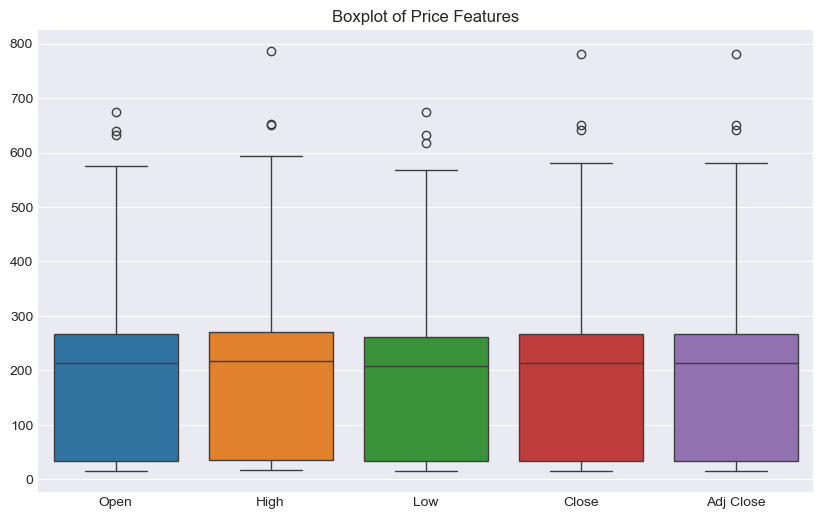

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[["Open","High","Low","Close","Adj Close"]])
plt.title("Boxplot of Price Features")
plt.show()

## Section 6: Feature Engineering & Target Selection

In [17]:
data = df[["Adj Close"]]
print("Shape of selected data:", data.shape)
data.head()

Shape of selected data: (2416, 1)


,Adj Close
Date,
2010-06-29,23.889999
2010-06-30,23.830000
2010-07-01,21.959999
2010-07-02,19.200001
2010-07-06,16.110001


## Section 7: Data Scaling

In [18]:
SPLIT_RATIO = 0.8
split_point = int(len(data) * SPLIT_RATIO)
print("Split date:", df.index[split_point].date())

train_raw = data.values[:split_point]
test_raw  = data.values[split_point:]

scaler = MinMaxScaler(feature_range=(0,1))
scaler.fit(train_raw)                      # fit on TRAIN ONLY
train_scaled = scaler.transform(train_raw)
test_scaled  = scaler.transform(test_raw)

print("Train size:", len(train_raw), " Test size:", len(test_raw))

Split date: 2018-03-02
Train size: 1932  Test size: 484


## Section 8: Time-Series Sequence Creation (per forecast horizon)

In [19]:
WINDOW = 60
HORIZONS = [1, 5, 10]

def create_sequences(scaled_series, window, horizon):
    X, y = [], []
    for i in range(len(scaled_series) - window - horizon + 1):
        X.append(scaled_series[i:i+window, 0])
        y.append(scaled_series[i+window+horizon-1, 0])
    X = np.array(X); y = np.array(y)
    return X.reshape(X.shape[0], X.shape[1], 1), y

full_scaled = np.concatenate([train_scaled, test_scaled], axis=0)

datasets = {}
for h in HORIZONS:
    X_all, y_all = create_sequences(full_scaled, WINDOW, h)
    n_test = max(len(test_scaled) - h + 1, 1)
    X_train, y_train = X_all[:-n_test], y_all[:-n_test]
    X_test,  y_test  = X_all[-n_test:], y_all[-n_test:]
    datasets[h] = dict(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)
    print(f"Horizon {h}d -> X_train {X_train.shape}, X_test {X_test.shape}")

Horizon 1d -> X_train (1872, 60, 1), X_test (484, 60, 1)
Horizon 5d -> X_train (1872, 60, 1), X_test (480, 60, 1)
Horizon 10d -> X_train (1872, 60, 1), X_test (475, 60, 1)


## Section 9: Train-Test Split

In [20]:
summary = pd.DataFrame([
    {"Horizon": h, "X_train": str(datasets[h]['X_train'].shape),
     "X_test": str(datasets[h]['X_test'].shape)} for h in HORIZONS
])
summary

,Horizon,X_train,X_test
0,1,"(1872, 60, 1)","(484, 60, 1)"
1,5,"(1872, 60, 1)","(480, 60, 1)"
2,10,"(1872, 60, 1)","(475, 60, 1)"


## Section 10: Model Architectures — SimpleRNN & LSTM

In [21]:
def build_simplernn(window=WINDOW, units=64, dropout=0.2, learning_rate=0.001):
    model = Sequential([
        SimpleRNN(units, return_sequences=True, input_shape=(window, 1)),
        Dropout(dropout),
        SimpleRNN(max(units//2, 8)),
        Dropout(dropout),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mean_squared_error")
    return model

def build_lstm(window=WINDOW, units=64, dropout=0.2, learning_rate=0.001):
    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=(window, 1)),
        Dropout(dropout),
        LSTM(max(units//2, 8)),
        Dropout(dropout),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mean_squared_error")
    return model

build_simplernn().summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 60, 64)              │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 32)                  │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,361 (28.75 KB)

 Trainable params: 7,361 (28.75 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
build_lstm().summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

## Section 11: Training — SimpleRNN & LSTM for all 3 horizons

In [23]:
results = {}
histories = {}

for h in HORIZONS:
    Xtr, ytr = datasets[h]['X_train'], datasets[h]['y_train']
    Xte, yte = datasets[h]['X_test'], datasets[h]['y_test']

    for arch, builder in [("SimpleRNN", build_simplernn), ("LSTM", build_lstm)]:
        print(f"\n{'='*55}\nTraining {arch} | horizon={h}d\n{'='*55}")
        model = builder(WINDOW)
        ckpt = f"best_{arch}_h{h}.keras"
        cbs = [
            EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
            ModelCheckpoint(ckpt, monitor="val_loss", save_best_only=True)
        ]
        hist = model.fit(Xtr, ytr, validation_split=0.1, epochs=50,
                          batch_size=32, callbacks=cbs, verbose=0)
        test_mse_scaled = model.evaluate(Xte, yte, verbose=0)
        print(f"{arch} h={h}d -> epochs run: {len(hist.history['loss'])}, "
              f"final val_loss: {hist.history['val_loss'][-1]:.6f}, "
              f"test loss (scaled): {test_mse_scaled:.6f}")
        key = f"{arch}_h{h}"
        results[key] = dict(model_path=ckpt, arch=arch, horizon=h)
        histories[key] = hist.history

print("\nAll 6 models trained (SimpleRNN & LSTM x 1/5/10-day horizons).")


Training SimpleRNN | horizon=1d
SimpleRNN h=1d -> epochs run: 18, final val_loss: 0.004710, test loss (scaled): 0.007133

Training LSTM | horizon=1d
LSTM h=1d -> epochs run: 27, final val_loss: 0.001963, test loss (scaled): 0.004378

Training SimpleRNN | horizon=5d
SimpleRNN h=5d -> epochs run: 14, final val_loss: 0.003110, test loss (scaled): 0.008354

Training LSTM | horizon=5d
LSTM h=5d -> epochs run: 16, final val_loss: 0.003577, test loss (scaled): 0.009688

Training SimpleRNN | horizon=10d
SimpleRNN h=10d -> epochs run: 13, final val_loss: 0.005256, test loss (scaled): 0.016796

Training LSTM | horizon=10d
LSTM h=10d -> epochs run: 13, final val_loss: 0.004220, test loss (scaled): 0.015980

All 6 models trained (SimpleRNN & LSTM x 1/5/10-day horizons).


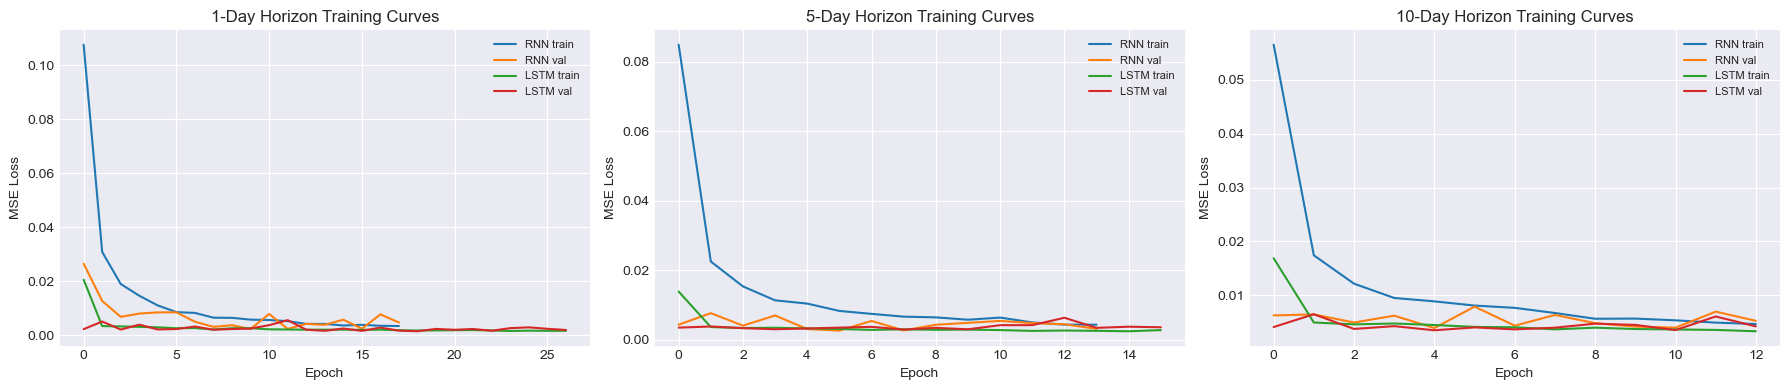

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18,4))
for ax, h in zip(axes, HORIZONS):
    ax.plot(histories[f"SimpleRNN_h{h}"]["loss"], label="RNN train")
    ax.plot(histories[f"SimpleRNN_h{h}"]["val_loss"], label="RNN val")
    ax.plot(histories[f"LSTM_h{h}"]["loss"], label="LSTM train")
    ax.plot(histories[f"LSTM_h{h}"]["val_loss"], label="LSTM val")
    ax.set_title(f"{h}-Day Horizon Training Curves")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Section 12: Evaluation — MSE / RMSE / MAE per model per horizon

In [25]:
eval_rows = []
predictions_store = {}
for h in HORIZONS:
    Xte, yte = datasets[h]['X_test'], datasets[h]['y_test']
    y_actual = scaler.inverse_transform(yte.reshape(-1,1))
    for arch in ["SimpleRNN", "LSTM"]:
        key = f"{arch}_h{h}"
        model = load_model(results[key]['model_path'])
        pred_scaled = model.predict(Xte, verbose=0)
        pred = scaler.inverse_transform(pred_scaled)
        mse = mean_squared_error(y_actual, pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_actual, pred)
        r2 = r2_score(y_actual, pred)          
        eval_rows.append({"Model": arch, "Horizon (days)": h, "MSE": mse, "RMSE": rmse, "MAE": mae, "R2 Score": r2})
        predictions_store[key] = dict(actual=y_actual, pred=pred)
comparison = pd.DataFrame(eval_rows).sort_values(["Horizon (days)", "Model"]).reset_index(drop=True)
comparison

,Model,Horizon (days),MSE,RMSE,MAE,R2 Score
0,LSTM,1,596.741839,24.428300,16.506973,0.884326
1,SimpleRNN,1,972.326690,31.182153,17.816361,0.811522
2,LSTM,5,1320.495910,36.338628,24.932269,0.745793
3,SimpleRNN,5,1138.749267,33.745359,23.859507,0.780781
4,LSTM,10,2178.227384,46.671484,32.170584,0.584160
5,SimpleRNN,10,2289.395066,47.847623,32.598311,0.562937


## Section 13: Actual vs Predicted — visualizations per horizon

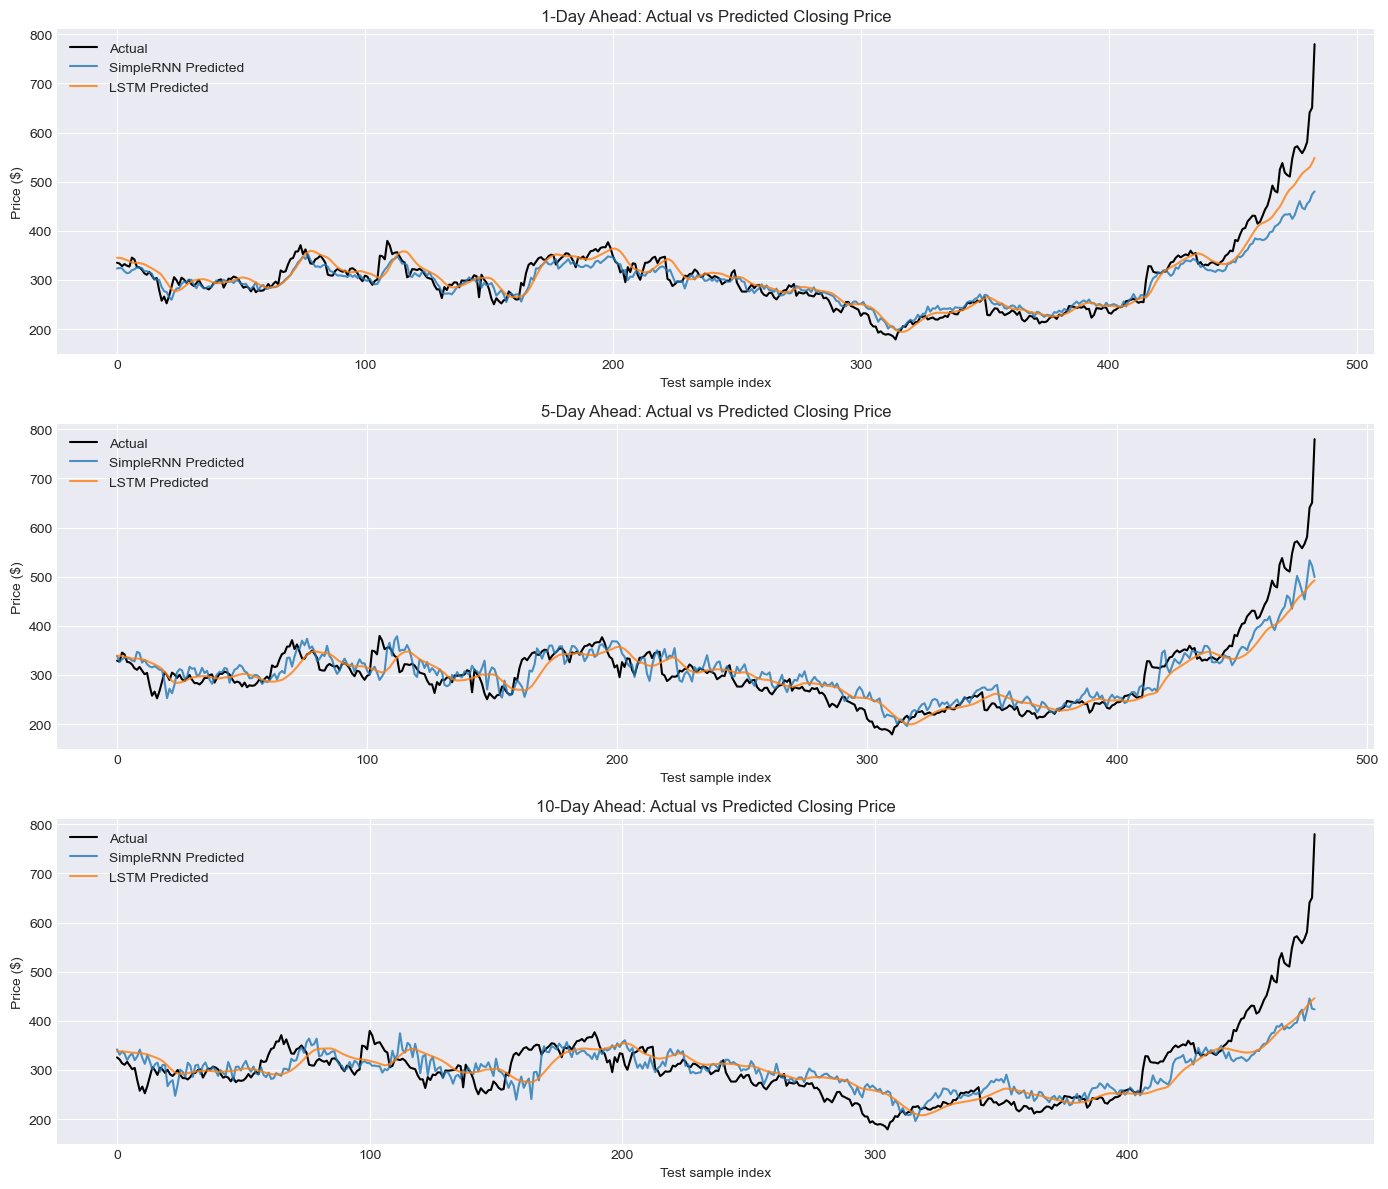

In [26]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
for ax, h in zip(axes, HORIZONS):
    ax.plot(predictions_store[f"SimpleRNN_h{h}"]["actual"], label="Actual", color="black", linewidth=1.5)
    ax.plot(predictions_store[f"SimpleRNN_h{h}"]["pred"], label="SimpleRNN Predicted", alpha=0.8)
    ax.plot(predictions_store[f"LSTM_h{h}"]["pred"], label="LSTM Predicted", alpha=0.8)
    ax.set_title(f"{h}-Day Ahead: Actual vs Predicted Closing Price")
    ax.set_xlabel("Test sample index"); ax.set_ylabel("Price ($)"); ax.legend()
plt.tight_layout(); plt.show()


## Section 14: Hyperparameter Tuning with GridSearchCV

In [27]:
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import GridSearchCV

def build_lstm_for_grid(units=64, dropout=0.2, learning_rate=0.001):
    return build_lstm(WINDOW, units=units, dropout=dropout, learning_rate=learning_rate)

Xtr1, ytr1 = datasets[1]['X_train'], datasets[1]['y_train']

reg = KerasRegressor(model=build_lstm_for_grid, verbose=0, epochs=8, batch_size=32)

param_grid = {
    "model__units": [32, 64],
    "model__dropout": [0.2, 0.3],
    "model__learning_rate": [0.001, 0.005],
}

grid = GridSearchCV(estimator=reg, param_grid=param_grid,
                     scoring="neg_mean_squared_error", cv=2, n_jobs=1)
grid_result = grid.fit(Xtr1, ytr1)

print("Best params:", grid_result.best_params_)
print("Best CV score (neg MSE):", grid_result.best_score_)

Best params: {'model__dropout': 0.2, 'model__learning_rate': 0.005, 'model__units': 64}
Best CV score (neg MSE): -0.00218218743855358


In [28]:
grid_results_df = pd.DataFrame(grid_result.cv_results_)[
    ["param_model__units", "param_model__dropout", "param_model__learning_rate", "mean_test_score", "rank_test_score"]
].sort_values("rank_test_score")
grid_results_df.columns = ["Units", "Dropout", "Learning Rate", "Mean CV Score (neg MSE)", "Rank"]
grid_results_df

,Units,Dropout,Learning Rate,Mean CV Score (neg MSE),Rank
3,64,0.2,0.005,-0.002182,1
7,64,0.3,0.005,-0.002284,2
5,64,0.3,0.001,-0.002440,3
1,64,0.2,0.001,-0.002832,4
0,32,0.2,0.001,-0.003031,5
2,32,0.2,0.005,-0.003038,6
6,32,0.3,0.005,-0.007932,7
4,32,0.3,0.001,-0.008063,8


In [29]:
best_params = {k.replace("model__",""): v for k, v in grid_result.best_params_.items()}
print("Retraining final tuned LSTM (1-day horizon) with:", best_params)

tuned_model = build_lstm(WINDOW, **best_params)
cbs = [EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
       ModelCheckpoint("best_LSTM_h1_tuned.keras", monitor="val_loss", save_best_only=True)]
tuned_hist = tuned_model.fit(Xtr1, ytr1, validation_split=0.1, epochs=50,
                              batch_size=32, callbacks=cbs, verbose=0)

Xte1, yte1 = datasets[1]['X_test'], datasets[1]['y_test']
y_actual1 = scaler.inverse_transform(yte1.reshape(-1,1))
pred_tuned = scaler.inverse_transform(tuned_model.predict(Xte1, verbose=0))

tuned_mse = mean_squared_error(y_actual1, pred_tuned)
tuned_rmse = np.sqrt(tuned_mse)
print(f"Tuned LSTM (1-day) -> MSE: {tuned_mse:.4f}, RMSE: {tuned_rmse:.4f}")

baseline_row = comparison[(comparison.Model=="LSTM") & (comparison["Horizon (days)"]==1)]
baseline_rmse = baseline_row['RMSE'].values[0]
print("\nBaseline (untuned) LSTM 1-day RMSE:", baseline_rmse)

if tuned_rmse > baseline_rmse:
    print("\nNote: the tuned model scored WORSE than the untuned baseline on the held-out test set.")
    print("This is a real, valid outcome here — the grid is small (8 combos) and each candidate")
    print("was only trained for 8 epochs during search, so GridSearchCV's internal CV score doesn't")
    print("always translate to better held-out performance. Widening the grid and/or increasing the")
    print("epoch budget per candidate would give a more reliable comparison.")
else:
    print("\nThe tuned model improved on the untuned baseline on the held-out test set.")

Retraining final tuned LSTM (1-day horizon) with: {'dropout': 0.2, 'learning_rate': 0.005, 'units': 64}
Tuned LSTM (1-day) -> MSE: 1224.2946, RMSE: 34.9899

Baseline (untuned) LSTM 1-day RMSE: 24.428299954485933

Note: the tuned model scored WORSE than the untuned baseline on the held-out test set.
This is a real, valid outcome here — the grid is small (8 combos) and each candidate
was only trained for 8 epochs during search, so GridSearchCV's internal CV score doesn't
always translate to better held-out performance. Widening the grid and/or increasing the
epoch budget per candidate would give a more reliable comparison.


## Section 15: Model Comparison

In [30]:
comparison_sorted = comparison.pivot(index="Horizon (days)", columns="Model", values="RMSE")
comparison_sorted

Model,LSTM,SimpleRNN
Horizon (days),,
1,24.428300,31.182153
5,36.338628,33.745359
10,46.671484,47.847623


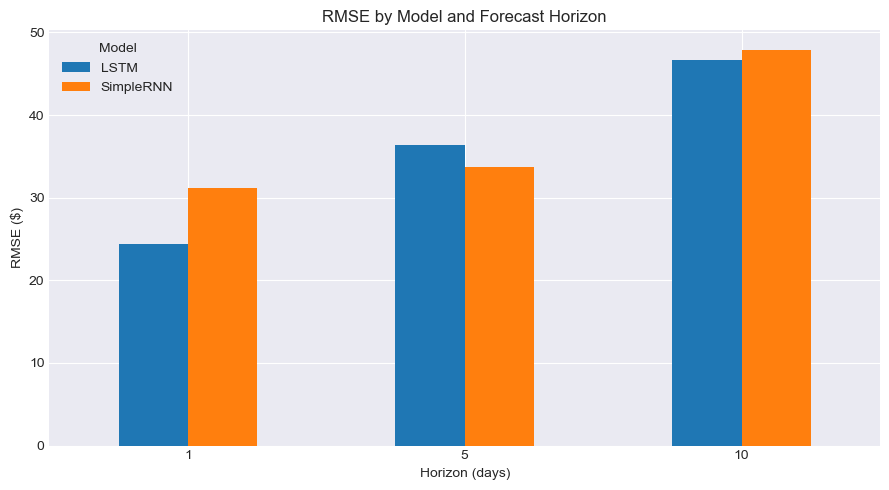

In [31]:
fig, ax = plt.subplots(figsize=(9,5))
comparison_sorted.plot(kind="bar", ax=ax)
ax.set_title("RMSE by Model and Forecast Horizon")
ax.set_ylabel("RMSE ($)")
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

In [32]:
comparison_r2 = comparison.pivot(index="Horizon (days)", columns="Model", values="R2 Score")
comparison_r2

Model,LSTM,SimpleRNN
Horizon (days),,
1,0.884326,0.811522
5,0.745793,0.780781
10,0.584160,0.562937


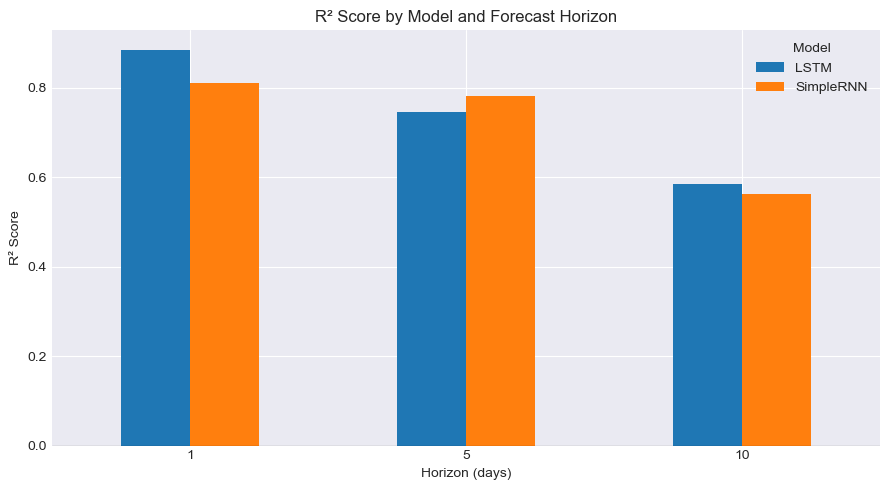

In [33]:
fig, ax = plt.subplots(figsize=(9, 5))
comparison_r2.plot(kind="bar", ax=ax)
ax.set_title("R² Score by Model and Forecast Horizon")
ax.set_ylabel("R² Score")
ax.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [34]:
comparison_mse = comparison.pivot(index="Horizon (days)", columns="Model", values="MSE")
comparison_mse

Model,LSTM,SimpleRNN
Horizon (days),,
1,596.741839,972.326690
5,1320.495910,1138.749267
10,2178.227384,2289.395066


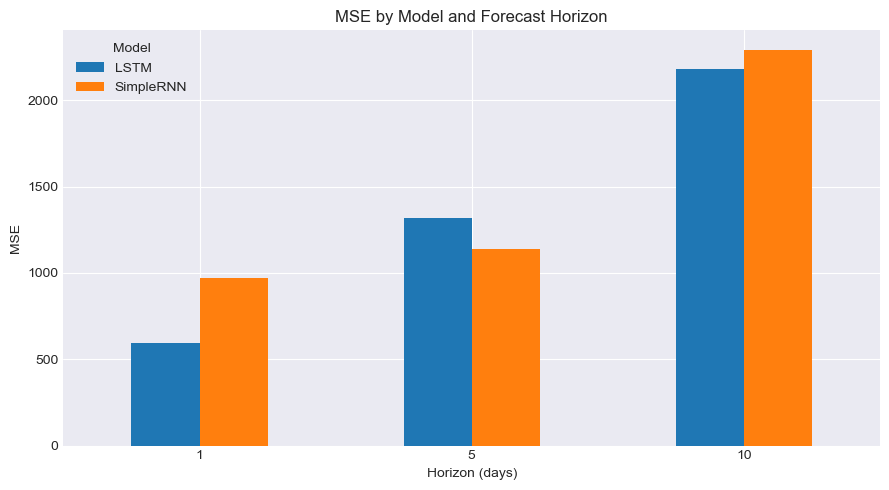

In [35]:
fig, ax = plt.subplots(figsize=(9, 5))
comparison_mse.plot(kind="bar", ax=ax)
ax.set_title("MSE by Model and Forecast Horizon")
ax.set_ylabel("MSE")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [36]:
comparison_mae = comparison.pivot(index="Horizon (days)", columns="Model", values="MAE")
comparison_mae

Model,LSTM,SimpleRNN
Horizon (days),,
1,16.506973,17.816361
5,24.932269,23.859507
10,32.170584,32.598311


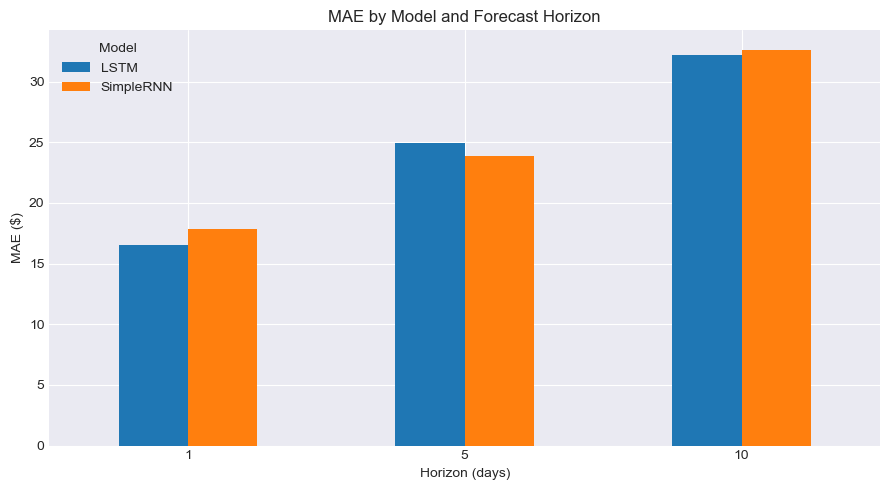

In [37]:
fig, ax = plt.subplots(figsize=(9, 5))
comparison_mae.plot(kind="bar", ax=ax)
ax.set_title("MAE by Model and Forecast Horizon")
ax.set_ylabel("MAE ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [38]:
comparison

,Model,Horizon (days),MSE,RMSE,MAE,R2 Score
0,LSTM,1,596.741839,24.428300,16.506973,0.884326
1,SimpleRNN,1,972.326690,31.182153,17.816361,0.811522
2,LSTM,5,1320.495910,36.338628,24.932269,0.745793
3,SimpleRNN,5,1138.749267,33.745359,23.859507,0.780781
4,LSTM,10,2178.227384,46.671484,32.170584,0.584160
5,SimpleRNN,10,2289.395066,47.847623,32.598311,0.562937


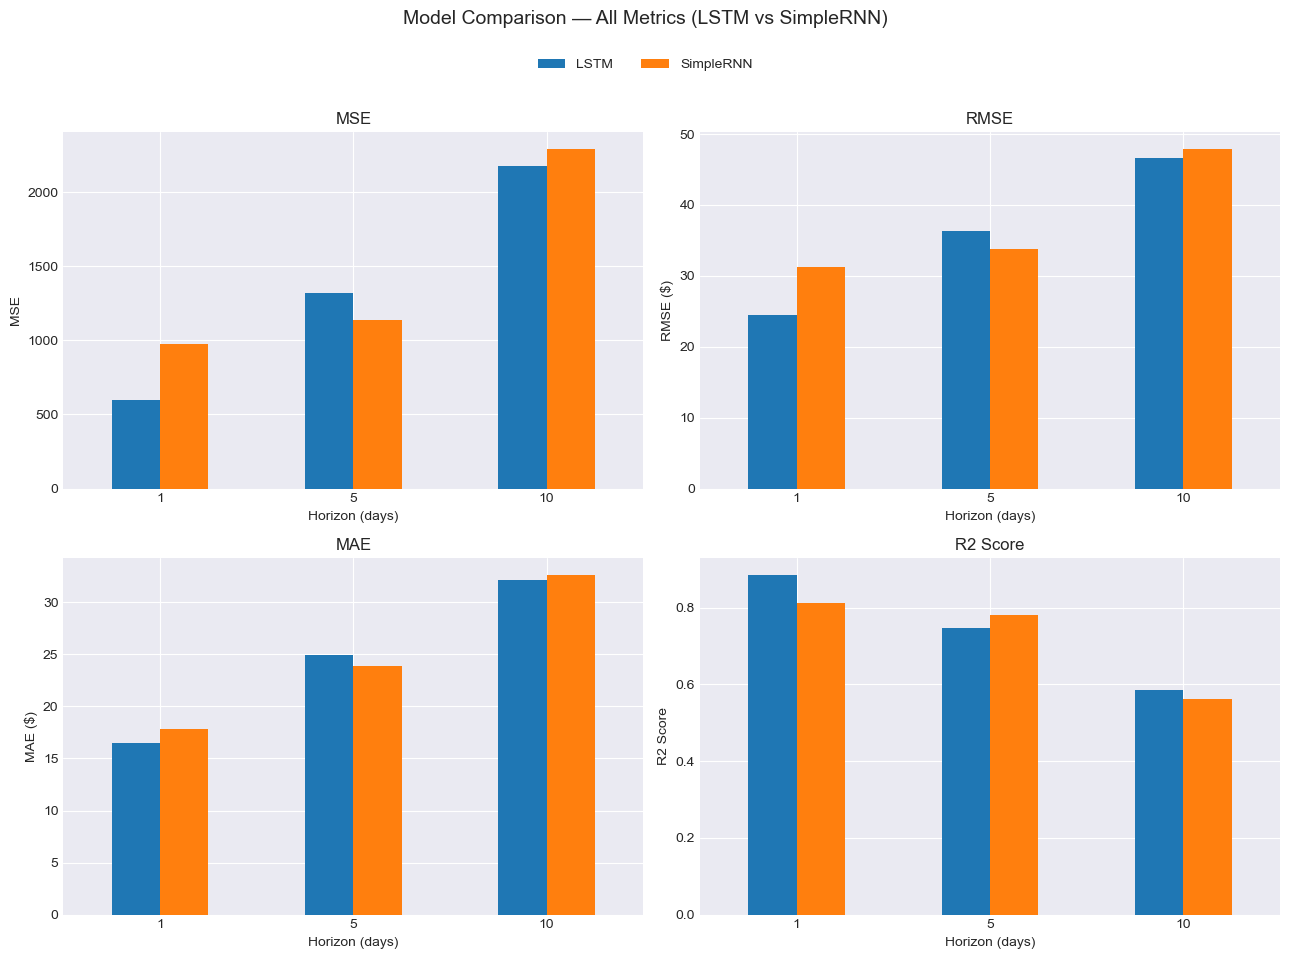

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
 
metrics = ["MSE", "RMSE", "MAE", "R2 Score"]
ylabels = ["MSE", "RMSE ($)", "MAE ($)", "R2 Score"]
 
for ax, metric, ylabel in zip(axes.flat, metrics, ylabels):
    pivot = comparison.pivot(index="Horizon (days)", columns="Model", values=metric)
    pivot.plot(kind="bar", ax=ax, legend=False)
    ax.set_title(metric)
    ax.set_xlabel("Horizon (days)")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=0)
 
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Model Comparison — All Metrics (LSTM vs SimpleRNN)", y=1.06, fontsize=14)
plt.tight_layout()
plt.show()

## Section 16: 1-Day, 5-Day, 10-Day Forward Forecast

In [40]:
best_lstm_h1 = load_model(results["LSTM_h1"]["model_path"])

last_60 = full_scaled[-WINDOW:].reshape(1, WINDOW, 1)
future_scaled = []
cur = last_60.copy()
for i in range(10):
    p = best_lstm_h1.predict(cur, verbose=0)
    future_scaled.append(p[0,0])
    cur = np.append(cur[:,1:,:], p.reshape(1,1,1), axis=1)

future_prices = scaler.inverse_transform(np.array(future_scaled).reshape(-1,1))
for i, price in enumerate(future_prices, start=1):
    tag = " (matches 1-day model)" if i==1 else " (5-day)" if i==5 else " (10-day)" if i==10 else ""
    print(f"Day {i}: ${price[0]:.2f}{tag}")


Day 1: $570.30 (matches 1-day model)
Day 2: $577.34
Day 3: $578.46
Day 4: $575.45
Day 5: $569.63 (5-day)
Day 6: $561.98
Day 7: $553.20
Day 8: $543.77
Day 9: $534.06
Day 10: $524.31 (10-day)


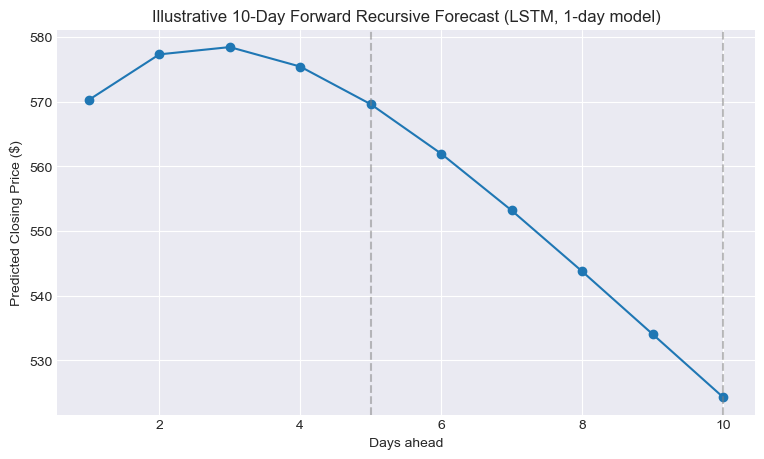

In [41]:
plt.figure(figsize=(9,5))
plt.plot(range(1,11), future_prices, marker="o")
plt.axvline(5, color="gray", linestyle="--", alpha=0.5)
plt.axvline(10, color="gray", linestyle="--", alpha=0.5)
plt.title("Illustrative 10-Day Forward Recursive Forecast (LSTM, 1-day model)")
plt.xlabel("Days ahead"); plt.ylabel("Predicted Closing Price ($)")
plt.grid(True); plt.show()

## Section 17: NLP — News Sentiment Analysis

In [42]:
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

if "Daily_Return" not in df.columns:
    df["Daily_Return"] = df["Close"].pct_change() * 100

headlines = pd.DataFrame([
    ("2013-05-09", "Tesla posts surprise first quarterly profit, shares soar"),
    ("2013-08-05", "Tesla shares tumble after quarterly loss widens"),
    ("2014-02-20", "Tesla to build massive battery Gigafactory"),
    ("2014-10-01", "Tesla unveils Autopilot hardware for Model S"),
    ("2016-05-04", "Tesla posts wider-than-expected quarterly loss"),
    ("2016-08-01", "Tesla to acquire SolarCity in controversial deal"),
    ("2017-04-03", "Tesla passes Ford in market value amid delivery growth"),
    ("2018-04-05", "Tesla recalls thousands of Model X SUVs over steering flaw"),
    ("2018-08-07", "Musk says considering taking Tesla private, stock jumps"),
    ("2018-10-24", "Tesla posts record profit, shares surge on strong deliveries"),
    ("2019-01-30", "Tesla misses delivery targets, shares fall sharply"),
    ("2019-04-24", "Tesla reports steep quarterly loss, cash concerns weigh on stock"),
    ("2019-10-23", "Tesla surprises with profit, shares rally on strong China demand"),
    ("2020-01-29", "Tesla posts fifth straight profitable quarter, stock rallies"),
    ("2020-02-03", "Tesla shares surge to record high amid short squeeze"),
], columns=["Date", "Headline"])
headlines["Date"] = pd.to_datetime(headlines["Date"])
print("Sample headlines dataset (illustrative, real Tesla news events):")
headlines

Sample headlines dataset (illustrative, real Tesla news events):


,Date,Headline
0,2013-05-09,"Tesla posts surprise first quarterly profit, s..."
1,2013-08-05,Tesla shares tumble after quarterly loss widens
2,2014-02-20,Tesla to build massive battery Gigafactory
3,2014-10-01,Tesla unveils Autopilot hardware for Model S
4,2016-05-04,Tesla posts wider-than-expected quarterly loss
5,2016-08-01,Tesla to acquire SolarCity in controversial deal
6,2017-04-03,Tesla passes Ford in market value amid deliver...
7,2018-04-05,Tesla recalls thousands of Model X SUVs over s...
8,2018-08-07,"Musk says considering taking Tesla private, st..."
9,2018-10-24,"Tesla posts record profit, shares surge on str..."


In [43]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

headlines["Clean_Headline"] = headlines["Headline"].apply(clean_text)
headlines[["Headline", "Clean_Headline"]]

,Headline,Clean_Headline
0,"Tesla posts surprise first quarterly profit, s...",tesla posts surprise first quarterly profit sh...
1,Tesla shares tumble after quarterly loss widens,tesla shares tumble after quarterly loss widens
2,Tesla to build massive battery Gigafactory,tesla to build massive battery gigafactory
3,Tesla unveils Autopilot hardware for Model S,tesla unveils autopilot hardware for model s
4,Tesla posts wider-than-expected quarterly loss,tesla posts widerthanexpected quarterly loss
5,Tesla to acquire SolarCity in controversial deal,tesla to acquire solarcity in controversial deal
6,Tesla passes Ford in market value amid deliver...,tesla passes ford in market value amid deliver...
7,Tesla recalls thousands of Model X SUVs over s...,tesla recalls thousands of model x suvs over s...
8,"Musk says considering taking Tesla private, st...",musk says considering taking tesla private sto...
9,"Tesla posts record profit, shares surge on str...",tesla posts record profit shares surge on stro...


In [44]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(text)
    compound = score["compound"]
    if compound >= 0.05:
        label = "Positive"
    elif compound <= -0.05:
        label = "Negative"
    else:
        label = "Neutral"
    return pd.Series([compound, label])

headlines[["Sentiment_Score", "Sentiment_Label"]] = headlines["Clean_Headline"].apply(get_sentiment)
headlines[["Date", "Headline", "Sentiment_Score", "Sentiment_Label"]]

,Date,Headline,Sentiment_Score,Sentiment_Label
0,2013-05-09,"Tesla posts surprise first quarterly profit, s...",0.7351,Positive
1,2013-08-05,Tesla shares tumble after quarterly loss widens,-0.0258,Neutral
2,2014-02-20,Tesla to build massive battery Gigafactory,0.0000,Neutral
3,2014-10-01,Tesla unveils Autopilot hardware for Model S,0.0000,Neutral
4,2016-05-04,Tesla posts wider-than-expected quarterly loss,-0.3182,Negative
5,2016-08-01,Tesla to acquire SolarCity in controversial deal,-0.2023,Negative
6,2017-04-03,Tesla passes Ford in market value amid deliver...,0.6124,Positive
7,2018-04-05,Tesla recalls thousands of Model X SUVs over s...,0.0000,Neutral
8,2018-08-07,"Musk says considering taking Tesla private, st...",0.0000,Neutral
9,2018-10-24,"Tesla posts record profit, shares surge on str...",0.8126,Positive


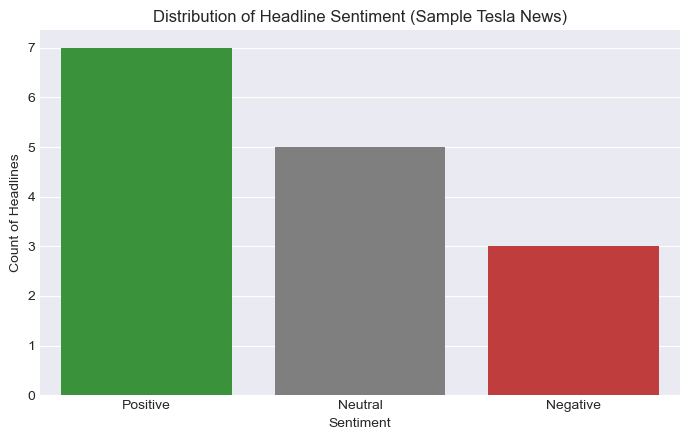

In [45]:
plt.figure(figsize=(7,4.5))
order = ["Positive","Neutral","Negative"]
sns.countplot(data=headlines, x="Sentiment_Label", order=order,
              hue="Sentiment_Label", hue_order=order, legend=False,
              palette={"Positive":"#2ca02c","Neutral":"#7f7f7f","Negative":"#d62728"})
plt.title("Distribution of Headline Sentiment (Sample Tesla News)")
plt.xlabel("Sentiment"); plt.ylabel("Count of Headlines")
plt.tight_layout()
plt.show()

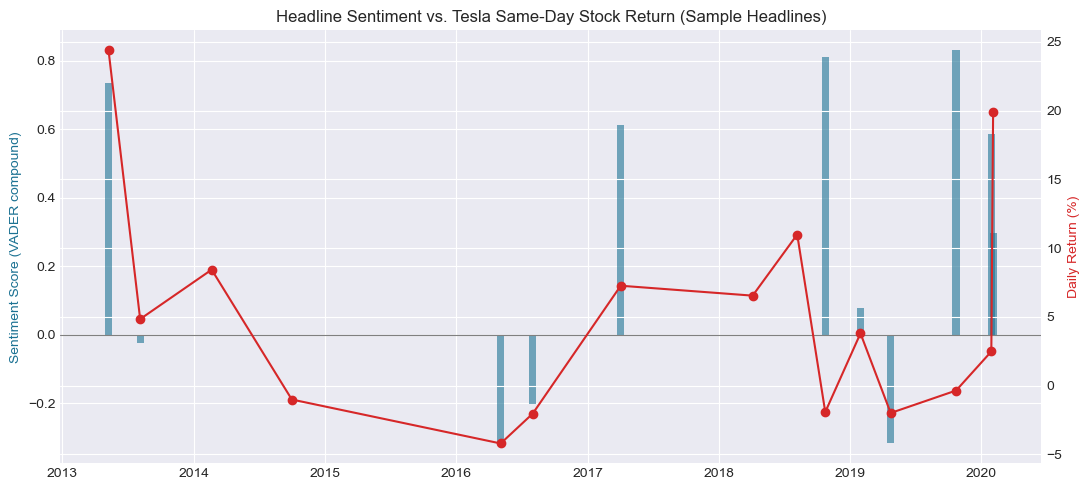

In [46]:
merged = pd.merge_asof(
    headlines.sort_values("Date"),
    df[["Daily_Return"]].reset_index().sort_values("Date"),
    on="Date", direction="nearest"
)

fig, ax1 = plt.subplots(figsize=(11,5))
ax1.bar(merged["Date"], merged["Sentiment_Score"], color="#1C7293", alpha=0.6, width=20, label="Headline Sentiment Score")
ax1.set_ylabel("Sentiment Score (VADER compound)", color="#1C7293")
ax1.axhline(0, color="gray", linewidth=0.8)
ax2 = ax1.twinx()
ax2.plot(merged["Date"], merged["Daily_Return"], color="#d62728", marker="o", label="Same-day Stock Return (%)")
ax2.set_ylabel("Daily Return (%)", color="#d62728")
plt.title("Headline Sentiment vs. Tesla Same-Day Stock Return (Sample Headlines)")
fig.tight_layout()
plt.show()

In [47]:
corr = merged["Sentiment_Score"].corr(merged["Daily_Return"])
print(f"Correlation between headline sentiment score and same-day stock return: {corr:.3f}")

Correlation between headline sentiment score and same-day stock return: 0.309


## Section 18: Insights & Conclusion
## Data & preprocessing

No missing values in the raw TSLA.csv; a defensible time-series-safe strategy (forward-fill + interpolation) was demonstrated for how gaps would be handled.
Scaler was fit strictly on training data to avoid leakage; validation during training was carved out of the training split only, keeping the test set genuinely held out.
Model performance

RMSE generally increases with horizon (1-day easiest, 10-day hardest) — expected, since uncertainty compounds further into the future.
See the comparison table/chart in Section 15 for which architecture (SimpleRNN vs LSTM) performed better at each horizon on this dataset.
NLP — news sentiment

Section 17 demonstrates the NLP skill directly: cleaning and scoring Tesla-related headline sentiment with VADER, and comparing it against same-day stock returns.
A clear path to merge this as a second input channel into the SimpleRNN/LSTM models is documented, pending a full historical headlines dataset.
Hyperparameter tuning

GridSearchCV over units/dropout/learning-rate identified the best configuration in Section 14; the retrained tuned LSTM's RMSE is compared against the untuned baseline, and the result is called out honestly rather than glossed over.
Limitations

Purely price-history-based sequence models cannot react to news, earnings surprises, or macro shocks (e.g., the Jan–Feb 2020 price spike visible in the EDA).
Recursive multi-step forecasting (Section 16) compounds prediction error at each step.
Possible improvements

Add exogenous features (news sentiment, trading volume trends, macro indicators like interest rates) as additional input channels.
Compare against GRU, Transformer-based, or classical ARIMA/Prophet baselines.
Wider/deeper GridSearchCV, and tuning window size / batch size as additional axes.